# **Lab 4: PySpark Basics in Databricks**

Lecturer: `Sirasit Lochanachit`


Course: `06026213 Big Data Systems`

Term: `02/2025`

Lab materials prepared by `Sasithorn (TA) - 2025`

## Step 0: Import functions and data types

การทำงานบน PySpark โดยทั่วไปจะต้องมีการเรียก SQL functions หรือ data types ของ Spark เอง

ดังนั้นควร import functions และ data types ที่ต้องการใช้โดยตรงจาก module ตามที่จำเป็นต้องใช้ (เพื่อหลีกเลี่ยงการ override built-in function ของ Python เอง)

[Pyspark SQL Functions](https://docs.databricks.com/aws/en/pyspark/reference/functions/)

[Pyspark Data Types](https://docs.databricks.com/aws/en/pyspark/reference/datatypes)

In [ ]:
# import select functions and types
from pyspark.sql.types import IntegerType, StringType
from pyspark.sql.functions import floor, round

# import modules using an alias
import pyspark.sql.types as T
import pyspark.sql.functions as F

# Step 1: Create a DataFrame

มีหลายวิธีในการสร้าง DataFrame ดังนี้

## a) With specified values

ใช้คำสั่ง `createDataFrame` ในการสร้าง DataFrame ใหม่ขึ้นมาโดยระบุค่าลงไปใน list ของ tuple เช่น

In [ ]:
df_children = spark.createDataFrame(
  data = [("Mikhail", 15), ("Zaky", 13), ("Zoya", 8)],
  schema = ['name', 'age'])
display(df_children)

In [ ]:
df_children.printSchema()

สังเกตว่า data type ในคำสั่งนี้ ถึงแม้จะไม่ได้ระบุโดยตรง แต่ Spark จะมีการระบุโดยอัตโนมติให้โดยวิเคราะห์จากตัวข้อมูล

หากต้องการระบุ data type เองให้กำหนดใน schema โดยใช้ `StructType` และ `StructFields` ดังนี้
- ใน StructFields หากอนุญาตให้มี null value ได้ ให้ระบุเป็น True

In [ ]:
from pyspark.sql.types import StructType, StructField, StringType, IntegerType

df_children_with_schema = spark.createDataFrame(
  data = [("Mikhail", 15), ("Zaky", 13), ("Zoya", 8)],
  schema = ['name', 'age'])
  
display(df_children_with_schema)

In [ ]:
df_children_with_schema.printSchema()

## b) From a table in Unity Catalog

ใช้ format `<catalog-name>.<schema-name>.<table-name>` ในการระบ table ใน catalog หรือ

Click Catalog -> Catalog Explorer -> Click table -> Select **Copy table path**

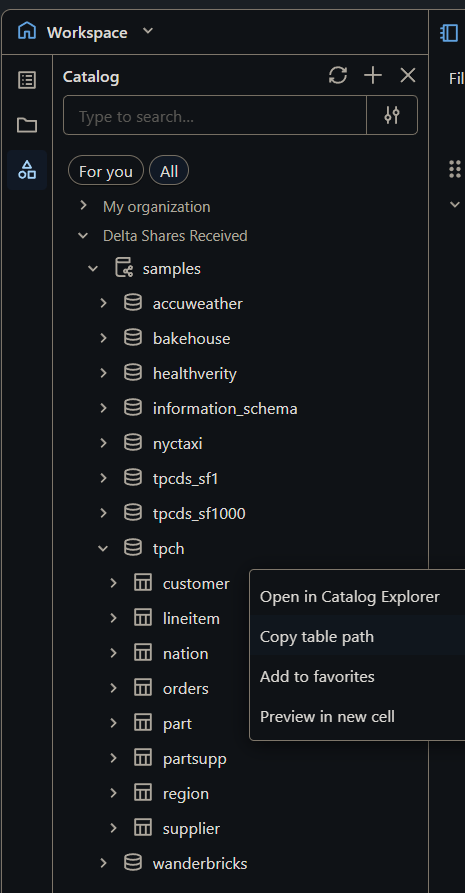

In [ ]:
df_customer = spark.table('')
display(df_customer)

## c) From an uploaded file

ดึงข้อมูลจากไฟล์ที่ upload ใน Unity Catalog Volumbes โดยใช้ `read` method
- Return `DataFrameReader` object เพื่อการอ่าน format ของไฟล์ที่ถูกต้อง
    - [DataFrameReader](https://api-docs.databricks.com/python/pyspark/latest/pyspark.sql/api/pyspark.sql.DataFrameReader.html)

ในตัวอย่างนี้ใช้ไฟล์ csv จาก Volume เดิมที่เคยทำไปแล้ว หรือจะลอง upload file เข้าไปใน volume อื่น ๆ แล้วลองดึงมาดูก็ได้เช่นกัน

In [ ]:
# Assign this variable your full volume file path
volume_file_path = ""

df_csv = (spark.read
  .format("csv")
  .option("header", True)
  .option("inferSchema", True)
  .load(volume_file_path)
)
display(df_csv)

## d) From a JSON response

ดึงข้อมูลจาก JSON Reponse payload ที่ return โดย REST API โดยการใช้ `requests` package ในการ query และ parse ตัว response

ตัวอย่างนี้จะใช้ไฟล์ JSON จาก [JSON_example](https://dummyjson.com/products)

In [ ]:
import requests

# Download data from URL
url = "https://dummyjson.com/products"
response = requests.get(url)

In [ ]:
# focus แค่ส่วนของ key: products
products = response.json()["products"]

In [ ]:
# สร้าง DataFrame จาก JSON ดังกล่าว
df_json = spark.createDataFrame(products)
display(df_json)

In [ ]:
df_json.printSchema()

# Step 2: Transform Data with DataFrames

DataFrames แปลงข้อมูลโดยใช้ built-in methods ไม่ว่าจะเป็นการ sort, filter และ aggregate 

ข้อควรระวัง: ไม่ใช่ทุก method จะมีอยู่ใน DataFrames แต่จะมีให้เรียกใช้จาก `pyspark.sql.functions`

## 2.1 Column Operations

### 2.1.1 Select Columns

หากต้องการดูทุก column ใน DataFrame ให้เรียกใช้ `columns` เช่น

In [ ]:
df_customer.columns

วิธีต่าง ๆ ในการเลือก column `Customer Key` และ `Account Balance`

1) ใช้ `col` function

In [ ]:
from pyspark.sql.functions import col

df_customer.select(
  col("c_custkey"),
  col("c_acctbal")
)

2) ใช้ SQL expression

In [ ]:
df_customer.selectExpr(
  "c_custkey as key",
  "round(c_acctbal) as account_rounded"
)

3) ใช้ string

In [ ]:
df_customer.select(
  "c_custkey",
  "c_acctbal"
)

4) ใช้ `[]` หรือ `.` operator แบบ pandas

In [ ]:
df_customer.select(
  df_customer["c_custkey"],
  df_customer["c_acctbal"]
)

In [ ]:
df_customer.select(
  df_customer.c_custkey,
  df_customer.c_acctbal
)

### 2.1.2 Create Columns

- ใช้ `withColumn(ชื่อ column ใหม่, เงื่อนไข)`

สร้าง column ใหม่ชื่อว่า `balance_flag` ที่เก็บค่าว่า Account Balance (`c_acctbal`) ของลูกค้ามีค่ามากกว่า 1000 หรือไม่

In [ ]:
df_customer_flag = df_customer.withColumn()

In [ ]:
display(df_customer_flag)

### 2.1.3 Rename Columns

- ใช้ `withColumnRenamed(ชื่อเดิม, ชื่อใหม่)`

เปลี่ยนชื่อ column จาก "balance_flag" เป็น "balance_flag_renamed"

In [ ]:
df_customer_flag_renamed = df_customer_flag.withColumnRenamed()

In [ ]:
display(df_customer_flag_renamed)

- ใช้ `alias` เมื่อต้องการเปลี่ยนชื่อของคอลัมน์ที่มาจากการทำ aggregate

คำนวณค่าเฉลี่ยของ account balance ของแต่ละ market segment แล้วตั้งชื่อ column ใหม่ว่า "avg_account_balance"

In [ ]:
from pyspark.sql.functions import avg

df_segment_balance = df_customer.groupBy("c_mktsegment").agg(
    avg(df_customer["c_acctbal"]).alias("avg_account_balance")
)

In [ ]:
display(df_segment_balance)

### 2.1.4 Cast Column Types

- เปลี่ยน data type ให้ใช้ `cast` ร่วมกันกับ `col`  

เปลี่ยน column "customerKey" จาก Integer -> String

In [ ]:
from pyspark.sql.functions import col

df_casted = df_customer.withColumn()
print(type(df_casted))

### 2.1.5 Remove Columns

- ใช้ `drop` method

ลบ column "balance_flag_renamed"

In [ ]:
df_customer_flag_renamed.drop()

ลบ column "c_phone" และ "balance_flag_renamed"

In [ ]:
df_customer_flag_renamed.drop()

## 2.2 Row Operations

### 2.2.1 Filter Rows

- `filter` หรือ `where` method

เลือกแถวลูกค้าที่มี CustomerKey = 412449

In [ ]:
from pyspark.sql.functions import col

df_that_one_customer = df_customer.filter()

เลือกแถวลูกค้าที่มี nationkey = 20 และ account balance > 1000

In [ ]:
display(df_customer.filter()

- ใช้เครื่องหมาย & (AND) หรือ | (OR)

เลือกแถวลูกค้าที่มี CustomerKey = 412446 หรือ 412447

In [ ]:
df_filtered_customer = df_customer.filter()

### 2.2.2 Remove Duplicate Rows

In [ ]:
df_unique = df_customer.distinct()

### 2.2.3 Handle null values

1) drop แถวที่ column ใด column หนึ่งมีค่า null

In [ ]:
df_customer_no_nulls = df_customer.na.drop()

หรือ

In [ ]:
df_customer_no_nulls = df_customer.na.drop("any")

2) หากต้องการลบแถวที่ทุก column มีค่า null

In [ ]:
df_customer_no_nulls = df_customer.na.drop("all")

3) ใช้แบบ `subset` คือ ถ้า column ที่อยู่ใน subset มีค่าเป็น null ถึงจะลบแถวนั้นออก

In [ ]:
df_customer_no_nulls = df_customer.na.drop("all", subset=["c_acctbal", "c_custkey"])

4. Fill missing values เช่น เติมค่า 0 ให้กับ account balance ที่มีค่าเป็น null

In [ ]:
df_customer_filled = df_customer.na.fill("0", subset=["c_acctbal"])

เพิ่มเติม: หากต้องการ `replace` ข้อมูลที่เป็น **empty string**

เช่นจาก "" กลายเป็น "UNKNOWN" ใน column "phone"

In [ ]:
df_customer_phone_filled = df_customer.na.replace([""], ["UNKNOWN"], subset=["c_phone"])

### 2.2.4 Append Rows

เช่น นำ `df_that_one_customer` (มี 1 แถว) กับ `df_filteterd_customer` (มี 2 แถว) มารวมกันเป็น 3 แถว โดยใช้ `union` method

In [ ]:
df_appended_rows = 

display(df_appended_rows)

### 2.2.5 Sort Rows

- ใช้ `sort` หรือ `orderBy`

Sort โดย Account Balance จากน้อยไปมาก

In [ ]:
# Default : Ascending Order
display(df_customer.orderBy()

Sort โดย CustomerKey จากมากไปน้อย

In [ ]:
# ใช้ desc() เพื่อเรียงจากมากไปน้อย
display(df_customer.sort()

Sort โดย Account Balance จากมากไปน้อย ตามด้วย Customer Key จากน้อยไปมาก

In [ ]:
# เรียงมากกว่า 1 คอลัมน์
df_sorted = df_customer.sort()

เพิ่มเติม: หากต้องการ limit จำนวน rows สามารถใช้ `limit` method

In [ ]:
display(df_sorted.limit(10))

## 2.3 Join DataFrames

การ Join ตั้งแต่ 2 DataFrames ขึ้นไปใช้ `join` โดยเลือกได้ว่าจะให้ join แบบไหน (`how`) รวมถึง join ด้วยคอลัมน์อะไร (`on`)
- inner (default): เก็บเฉพาะแถวที่มีการ match กับ on เท่านั้น
- left :  เก็บทุกแถวจาก DataFrame แรก และเก็บเฉพาะแถวจาก DataFrame ที่สองที่ match กับ DataFrame แรกเท่านั้น
- outer : เก็บทุกแถวแบบไม่สนใจว่ามันจะ match หรือไม่

ตัวอย่าง: Inner Join ข้อมูลระหว่าง orders และ customer DF ผ่าน CustomerKey

In [ ]:
df_customer = spark.table('samples.tpch.customer')
df_order = spark.table('samples.tpch.orders')

df_joined = df_order.join(
  df_customer,
  on = ,
  how = 
)

display(df_joined)

หากเงื่อนไขการ join มีมากกว่า 1 เงื่อนไข ให้ใช้ boolean operators เช่น `&` หรือ `|`

ตัวอย่าง: Inner Join ข้อมูลระหว่าง orders และ customer DF ผ่าน CustomerKey เฉพาะข้อมูล order ที่มียอดขายมูลค่ามากกว่า 500,000 ขึ้นไป

In [ ]:
df_customer = spark.table('samples.tpch.customer')
df_order = spark.table('samples.tpch.orders')

df_complex_joined = df_order.join(
  df_customer,
  on = ,
  how = 
)

display(df_complex_joined)

## 2.4 Aggregate Data

ในการรวมข้อมูล (aggregate) ใน DataFrame คล้ายกับการรวมข้อมูล GROUP BY ใน SQL โดยการใช้ `groupBy` เพื่อระบุคอลัมน์ที่จะใช้ในการจัดกลุ่ม และ `agg` เพื่อระบุวิธีในการรวมข้อมูล 

และ import aggregations ทั่วไป เช่น `avg`, `sum`, `max`, และ `min` จาก pyspark.sql.functions 

ตัวอย่าง: การแสดงยอด Account Balance เฉลี่ยของลูกค้าแยกตาม market segment

In [ ]:
from pyspark.sql.functions import avg

# group by one column
df_segment_balance = df_customer.groupBy().agg(
    avg()
)

display(df_segment_balance)

ตัวอย่าง: การแสดงยอด Account Balance เฉลี่ยของลูกค้าแยกตาม market segment และ NationKey

In [ ]:
from pyspark.sql.functions import avg

# group by two columns
df_segment_nation_balance = df_customer.groupBy().agg(
    avg()
)

display(df_segment_nation_balance)

เพิ่มเติม: การนับแถวใน DF

In [ ]:
df_segment_balance.count()

## 2.5 Chaining Calls

การประยุกต์ใช้ Lazy Evaluation กล่าวคือ การที่เราเขียนเป็นขั้นตอนต่างๆมาก่อน ไม่ว่าจะเป็นการ filter หรือการ aggregate ต่างๆ spark จะเตรียมเป็น **Execution Plan** แล้วหลังจากนั้นค่อยทำรวดเดียวจบเมื่อเจอคำสั่ง **Action** เช่น display
- Method ที่เป็น transformation จะสร้าง DataFrame ใหม่ขึ้นมา (ก็ต่อเมื่อมี action call เท่านั้น)


ตัวอย่าง: การ chain filtering, aggregation และ ordering

In [ ]:
from pyspark.sql.functions import count

df_chained = (
    df_order.filter(col("o_orderstatus") == "F") # 1. Filter
    .groupBy(col("o_orderpriority")) # 2. Group By
    .agg(count(col("o_orderkey")).alias("n_orders")) # 3. Aggregation
    .sort(col("n_orders").desc()) # 4. Sort
)

display(df_chained)

# Step 3: Save your data

หลังจากที่แปลงข้อมูลเรียบร้อยแล้ว สามารถบันทึกโดยใช้ `DataFrameWriter` method

[DataFrameWriter](https://api-docs.databricks.com/python/pyspark/latest/pyspark.sql/api/pyspark.sql.DataFrameWriter.html)

## a) Save your DataFrame as a table

หากต้องการบันทึกเป็น tabe ใน Unity Catalog
- ใช้ path ในรูปแบบ `catalog-name.schema-name.table-name`
- ใช้คำสั่ง `write.saveAsTable()`

In [ ]:
df_joined.write.saveAsTable(f"bds.bds0.customer_info")

## b) Write your DataFrame as CSV

สามารถ save ในรูปแบบ CSV file ได้ โดยใช้ `write`
และมี mode ให้เลือก 3 modes คือ
- `overwrite` คำสั่งนี้จะเขียนทับข้อมูลที่มีอยู่ทั้งหมดใน path ที่กำหนดด้วย DataFrame ที่ต้องการจะ save ปัจจุบัน
- `append` เพิ่มเนื้อหาของ DataFrame ต่อท้ายข้อมูลใน path ที่กำหนด
- `ignore` ถ้ามีข้อมูลอยู่ใน path ที่ระบุไว้อยู่แล้ว จะ fails แบบเงียบๆ (ไม่มี error)

In [ ]:
# Assign this variable your file path
file_path = "/Volumes/bds/bds0/bds_volume/cust_info/"

(df_joined.write
  .format("csv")
  .mode("overwrite")
  .save(file_path)
)

ปกติการ save csv แบบโค้ดข้างบน ถ้าไฟล์มีขนาดใหญ่ จะมีการแบ่งเก็บเป็นไฟล์ย่อยๆแยกออกไปตามความเหมาะสมที่ระบบจะจัดให้ ใน path ที่เรากำหนด (ดูผลลัพธ์ได้จากใน volume หรือ path ที่เรา save ไว้ หรือลองดูภาพตัวอย่างหลังจาก save แล้วใน doc) หากต้องการ save แบบไฟล์เดียว ไม่แบ่ง (แต่ไฟล์จะใหญ่มาก) ให้ลองใช้คำสั่งด้านล่าง

- `.coalesce(1)` : ลด partition ลง เหลือเพียง 1 ไฟล์ 
-  `.option("header", "true")` : ให้ save header ด้วย

In [ ]:
(df_joined
 .coalesce(1)
 .write
 .option("header", "true")
 .mode("overwrite")
 .csv("/Volumes/bds/bds0/bds_volume/cust_info_csv_ver")
)

---